# Hydrophobic surface patches of a PDB protein

This example downloads [1CRN (crambin)](https://www.rcsb.org/structure/1CRN) from the Protein Data Bank, calculates its MSMS surface, maps residue hydrophobicity to that surface, finds connected patches, and displays them over a blue protein cartoon. No synthetic molecule or manually assigned electrostatic charges are used.

Requirements: an internet connection for the PDB download and an `msms` executable on `PATH`. The optional OpenMM charge section at the end also requires `biotools[contacts]`.

In [ ]:
import shutil
from tempfile import TemporaryDirectory

from biotools.structure import (
    calculate_molecular_surface,
    find_surface_patches,
    get_pdb_structure,
    map_hydrophobicity,
    plot_molecular_surface,
)

if shutil.which("msms") is None:
    raise RuntimeError("MSMS must be installed and available on PATH")

## Download and load 1CRN

The download is held in a temporary directory; the parsed Biopython structure remains usable after that directory is removed.

In [2]:
with TemporaryDirectory(prefix="biotools-1crn-") as download_dir:
    structure = get_pdb_structure("1crn", target_folder=download_dir)

print(f"PDB: {structure.id}; atoms: {sum(1 for _ in structure.get_atoms())}")

PDB: 1crn; atoms: 327


## Calculate the molecular surface and hydrophobicity

The surface uses the protein atoms, excluding crystallographic water. The default Kyte–Doolittle residue scale supplies a hydrophobicity value for each surface vertex.

In [3]:
surface = calculate_molecular_surface(
    structure,
    include_heteroatoms=False,
    probe_radius=1.5,
    density=1.0,
)
surface = map_hydrophobicity(surface)

mesh = surface.surface
print(f"MSMS {surface.backend_version}: {len(mesh.vertices)} vertices, {len(mesh.faces)} faces")

MSMS 2.6.1: 2350 vertices, 4696 faces


## Find connected hydrophobic patches

Faces with mean hydrophobicity at least `1.0` are grouped by shared edges. Patches smaller than 10 Å² are omitted. `face_labels == -1` marks the remaining surface.

In [4]:
patches = find_surface_patches(
    surface,
    field_name="hydrophobicity",
    threshold=1.0,
    min_area=10.0,
)

print(f"Hydrophobic patches: {len(patches.patches)}")
for patch in patches.patches:
    print(f"Patch {patch.patch_id}: {patch.area:.1f} Å²")

Hydrophobic patches: 3
Patch 0: 454.6 Å²
Patch 1: 153.1 Å²
Patch 2: 129.4 Å²


In [13]:
surface = calculate_molecular_surface(
    structure,
    include_heteroatoms=False,
    density=3.0,
)
surface = map_hydrophobicity(surface)

view = plot_molecular_surface(
    structure,
    surface,
    structure_style={"cartoon": {"color": "blue"}},
    field_name="hydrophobicity",
    cmap="coolwarm",
    field_range=(-4.5, 4.5),
    field_center=0.0,
    colorbar=True,
    surface_opacity=0.65,
)
view

3Dmol.js failed to load for some reason. Please check your browser console for error messages.

3Dmol.js failed to load for some reason. Please check your browser console for error messages.

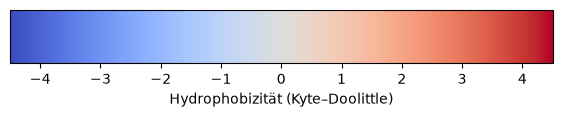

In [14]:
import matplotlib.pyplot as plt
from matplotlib.cm import ScalarMappable
from matplotlib.colors import TwoSlopeNorm
from IPython.display import display

display(view)

fig, ax = plt.subplots(figsize=(7, 0.7))
fig.colorbar(
    ScalarMappable(
        norm=TwoSlopeNorm(vmin=-4.5, vcenter=0.0, vmax=4.5),
        cmap="coolwarm",
    ),
    cax=ax,
    orientation="horizontal",
    label="Hydrophobizität (Kyte–Doolittle)",
)
plt.show()

## Display the patches with the protein cartoon

`plot_molecular_surface()` uses py3Dmol. The protein cartoon is blue, while connected patches receive distinct colors and the rest of the surface is light gray.

In [5]:
view = plot_molecular_surface(
    structure,
    surface,
    structure_style={"cartoon": {"color": "blue"}},
    patches=patches,
    surface_opacity=0.65,
    width=900,
    height=550,
)
view

3Dmol.js failed to load for some reason. Please check your browser console for error messages.

## Electrostatic surface potential from OpenMM charges

The same 1CRN structure and MSMS surface can also be colored by electrostatic potential. OpenMM assigns force-field partial charges **per atom** and adds missing hydrogens in memory; no manual residue-charge table is needed. The field below is a constant-dielectric Coulomb potential, not a solvent-screened Poisson–Boltzmann calculation. Install the optional backend with `pip install -e '.[contacts]'`.

In [12]:
import numpy as np
from biotools.structure import map_electrostatic_potential_openmm

charged_surface = map_electrostatic_potential_openmm(
    structure,
    surface,
    forcefield_files=("amber14-all.xml",),
    add_hydrogens=True,
    ph=7.4,
    dielectric=4.0,
)
potential = charged_surface.surface.get_field("electrostatic_potential")
limit = float(np.max(np.abs(potential.values)))
print(f"Potential range: {np.min(potential.values):.1f} to {np.max(potential.values):.1f} {potential.units}")

charge_view = plot_molecular_surface(
    structure,
    charged_surface,
    structure_style={"cartoon": {"color": "blue"}},
    field_name="electrostatic_potential",
    cmap="coolwarm",
    field_range=(-limit, limit),
    field_center=0.0,
    colorbar=True,
    surface_opacity=0.92,
    width=900,
    height=550,
)
charge_view

Potential range: -147.9 to 175.1 kJ mol^-1 e^-1


3Dmol.js failed to load for some reason. Please check your browser console for error messages.

In [ ]:
# Show only the largest hydrophobic patch, colored by its field values.
largest_patch = max(patches.patches, key=lambda patch: patch.area)
largest_view = plot_molecular_surface(
    structure,
    surface,
    patch=largest_patch,
    field_name="hydrophobicity",
    cmap="coolwarm",
    colorbar=True,
    structure_style={"cartoon": {"color": "blue"}},
    surface_opacity=0.8,
)
largest_view